In [1]:
# heatmap 상관계수를 매트릭스 시각화
# pairplot으로 전체 변수 관계 한눈에 파악
# 다변량 패턴 발견 및 변수 선택

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 한글폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
# 어떤 값들이 서로 연결되어 있나?
numeric_cols = iris.describe().columns
corr_matrix = iris[numeric_cols].corr()
corr_matrix.round(3)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


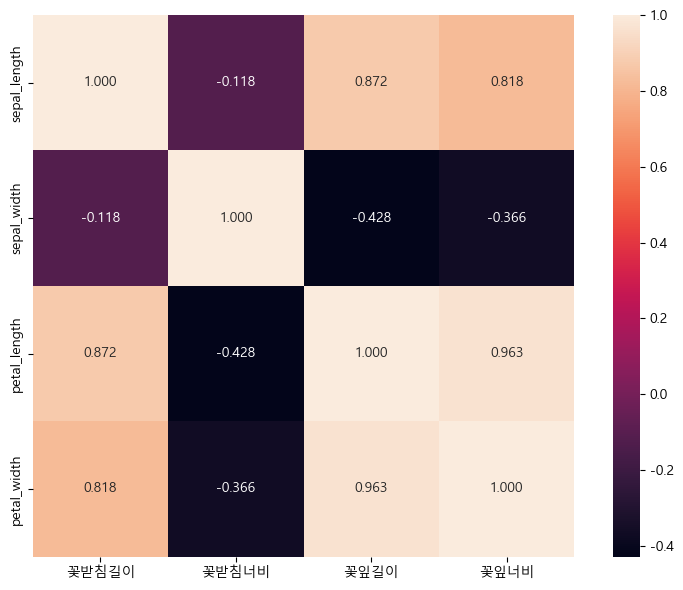

In [7]:
fig, ax = plt.subplots(figsize = (8,6))
sns.heatmap(data = corr_matrix, annot=True, fmt='.3f', ax=ax, square=True)
labels = ['꽃받침길이', '꽃받침너비', '꽃잎길이', '꽃잎너비']
ax.set_xticklabels(labels)
ax.get_yticklabels(labels)
plt.tight_layout()
plt.show()

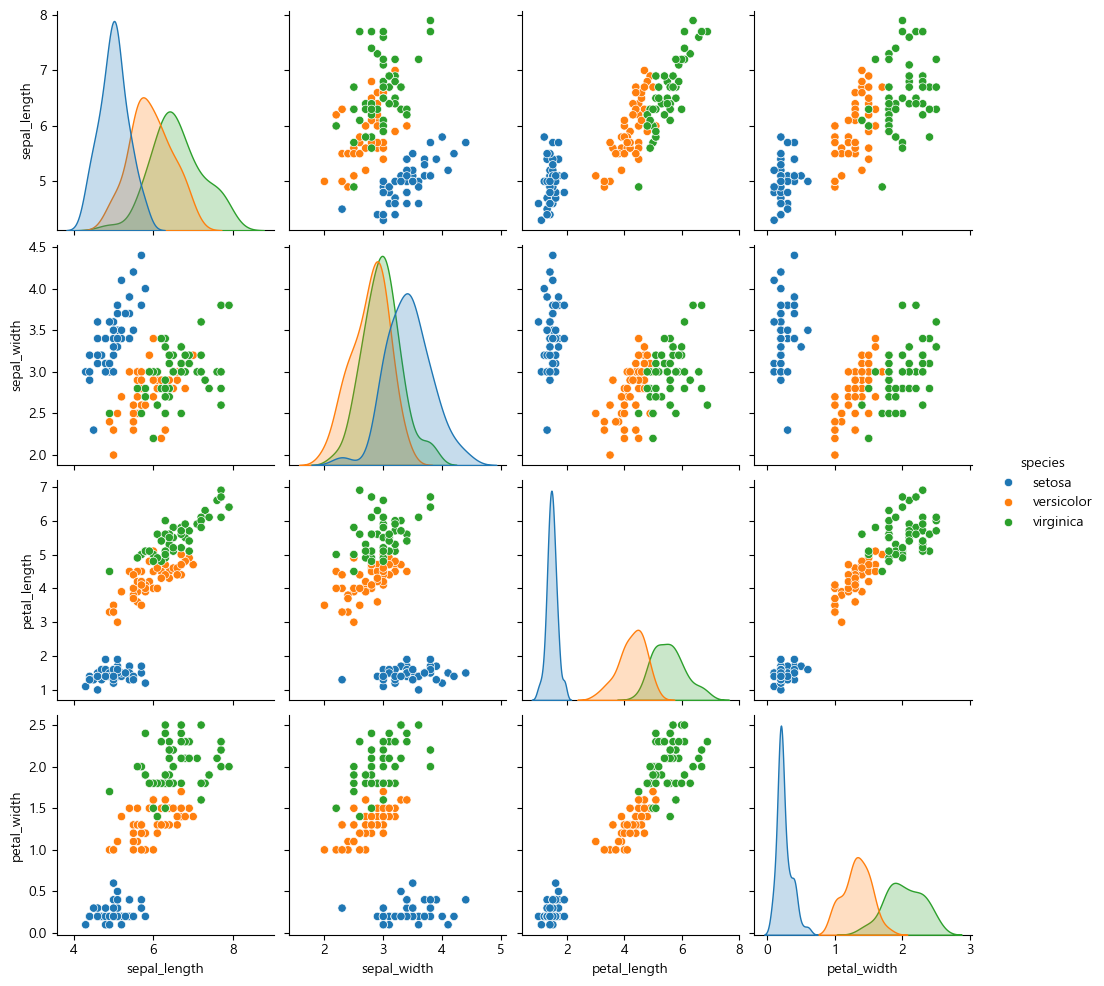

In [6]:
# 모든 조합을 시각화 pairplot
sns.pairplot(iris,hue='species')

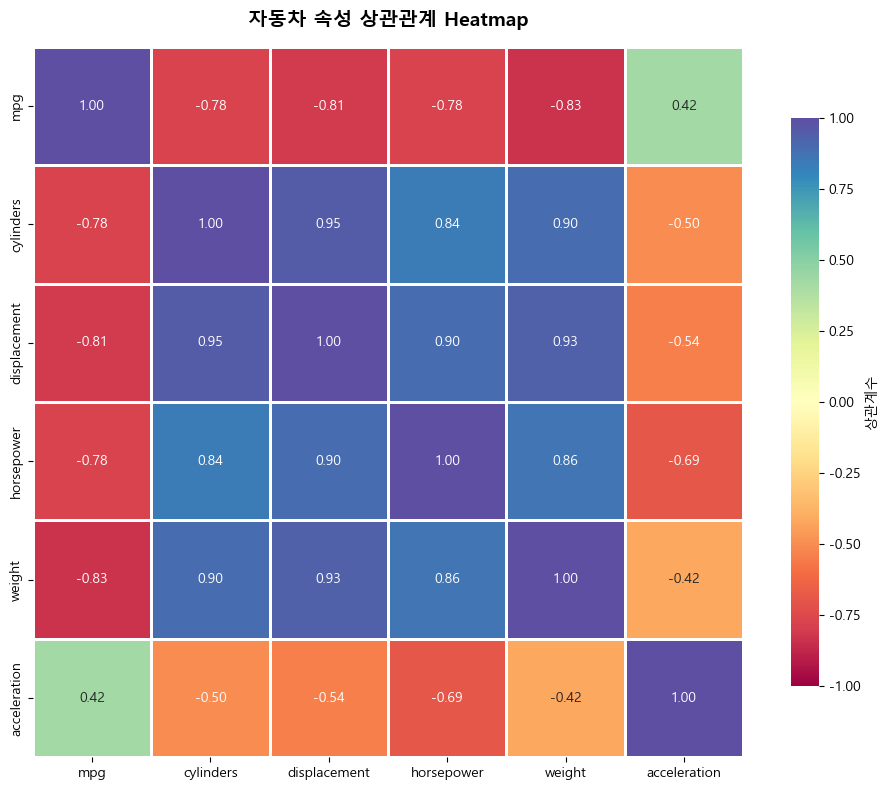


연비(mpg)와의 상관계수:
mpg             1.000000
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


In [9]:
# 자동차 데이터를 heatmap
# 연비 향상 요인 분석
# 1. 연비에 영향을 주는 변수들(상관관계 강한 양수 음수)
#2. 연비에 영향을 주는 변수들끼리의 강관관계 - 다중공선성 문제 (서로 0.9 이상 상관)
# 연비와 약한 양의 상관관계 -> 독립적인 정보

# MPG 데이터 로드
mpg = sns.load_dataset('mpg')

# 수치형 변수만 선택
mpg_numeric = mpg[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].dropna()
mpg_corr = mpg_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap 생성
sns.heatmap(mpg_corr, annot=True, fmt='.2f', cmap='Spectral',
            center=0, square=True, linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('자동차 속성 상관관계 Heatmap', fontsize=14, fontweight='bold', pad=15)

# # 레이블 한글화
# mpg_labels = ['연비', '실린더', '배기량', '마력', '무게', '가속']
# ax.set_xticklabels(mpg_labels, rotation=45, ha='right')
# ax.set_yticklabels(mpg_labels, rotation=0)

plt.tight_layout()
plt.show()

# 강한 상관관계 추출
print("\n연비(mpg)와의 상관계수:")
print(mpg_corr['mpg'].sort_values(ascending=False))

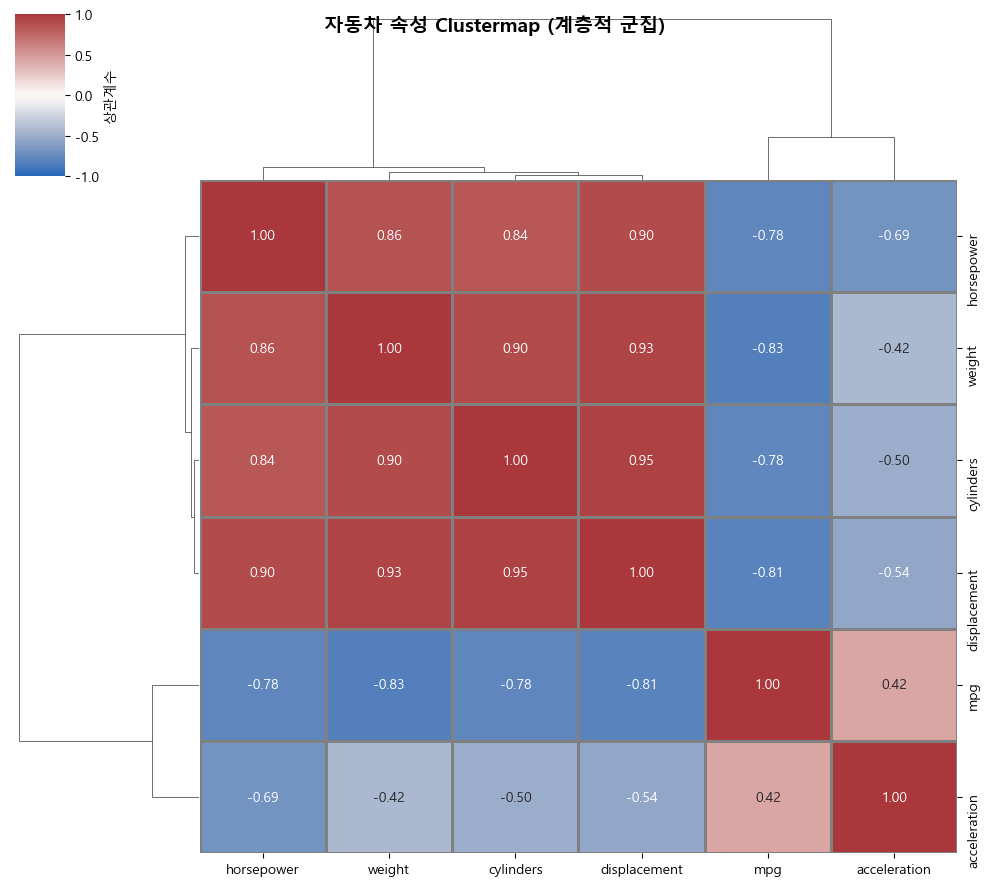

In [11]:
# 계층적 군집화 : ClusterMap

g = sns.clustermap(mpg_corr, annot=True, fmt='.2f', cmap='vlag',
                   center=0, linewidths=1, linecolor='gray',
                   cbar_kws={'label': '상관계수'},
                   figsize=(10, 9), vmin=-1, vmax=1)

g.fig.suptitle('자동차 속성 Clustermap (계층적 군집)', fontsize=14, fontweight='bold', y=0.98)

plt.show()